# Regresión logística

### Partamos de una regresión lineal

Recordemos el modelo más simple de regresión: **la regresión lineal**. En un modelo lineal, la salida se obtiene combinando linealmente las características de entrada:

$$z = w^{\top} x + b$$

donde $w$ es un vector de pesos, $b$ es un sesgo, y $x$ es un vector de características en $\mathbb{R}^N$.  
La salida $z$ es un valor real no acotado, que puede interpretarse como una **estimación lineal** o como una medida continua relacionada con la evidencia a favor de cierta respuesta.

En un contexto de clasificación binaria, el modelo lineal define un **hiperplano de separación** mediante la ecuación:

$$z = w^{\top} x + b = 0$$

El vector $w$ es **perpendicular** (normal) al hiperplano, y el valor $z$ es **la distancia con signo (no normalizada)** del punto $x$ al hiperplano, que podemos intepretar como **evidencia de pertenencia a la clase**. Es importante notar que esta cantidad de evidencia (valor de $z$) no está acotado (recorrido: $-\infty$ hasta $+\infty$)  

### Función de activación sigmoide

Sin embargo, para obtener una **probabilidad** necesitamos transformar $z$ (que puede tomar cualquier valor real) en un número entre 0 y 1. Para ello usamos la **función sigmoide**:

$$\sigma(z) = \frac{1}{1 + e^{-z}}$$

donde $$z = (w^{\top} x+b)$$

Esta función convierte la salida del modelo lineal en una probabilidad

$$\hat{y} = P(y = 1 \mid x) \in (0,1)$$

y, claramente, la probabilidad de pertenencia a la clase que queda por debajo es $P(y=0 | x) = 1 - P(y=1 | x) = 1-p$.

Gracias a esto, podremos entrenar un clasificador que distinga entre dos categorías (en este ejercicio, imágenes de **seises** y **ochos**).

### Clasificación
Para clasificar un punto de datos, que es un vector $N$-dimensional $x$ de componentes $x_{i}$, comenzamos calculando la distancia (*no normalizada* y con signo: puede ser positiva o negativa) del punto al hiperplano $w^{\top}x+b$. Formalmente:

$$d_{signed\ no\ norm} = (w^{\top} x+b)$$

<br>

*Para homogeneizar el cálculo, es habitual trabajar con vectores de $N+1$ componentes y fijar $x_{1} = 1$ con lo que $w_{1} = b$, y podemos escribir, simplemente:*

$$d_{signed\ no\ norm} = (w^{\top} x)$$

*Se trata de la misma cosa, tan solo hay que dejar claro el convenio que se sigue. Para esta práctica, trabajaremos explícitamente con el sesgo* $b$.
<br><br>

Una forma útil de interpretar este valor (no acotado) es como *evidencia* de pertenencia a una clase: mientras más positiva sea la distancia al hiperplano, mayor evidencia a favor; mientras más negativa, mayor evidencia en contra.


Por la naturaleza del algoritmo, la clasificación es inherentemente bi-clase. Si queremos trabajar con $K$ clases, tendremos que generalizar estos resultados. En este ejercicio, vamos a filtrar los datos para distinguir solamente entre dos categorías: **seises** y **ochos**.
<br><br>
### Entrenamiento

La función de pérdida usada es la *entropía cruzada*, que se puede interpretar como la distancia entre dos distribuciones de probabilidad de las dos variables aleatorias $y$ e $\hat{y}$:

$$L = -\left[ y^{m} \log(\hat{y^{m}}) + (1 - y^{m}) \log(1 - \hat{y^{m}}) \right]$$

No resulta excesivamente difícil calcular la expresión del gradiente dada esta función de pérdida:

$$\frac{\partial L^m}{\partial z^m}
= \frac{\partial L^m}{\partial \hat{y^{m}}} \cdot \frac{d \hat{y^{m}}}{d z^m}
= (\hat{y^{m}} - y^m)$$
<br>
$$\nabla_w L^m = (\hat{y^{m}} - y^m) x^m
\\
\frac{\partial L^m}{\partial b} = \hat{y^{m}} - y^m$$


Y de aquí, la regla de actualización en lote (batch) para un conjunto de datos de M puntos:

$$w \leftarrow w - \eta \frac{1}{M}\sum_{m=1}^{M}(\hat{y^{m}} - y^{m})x^{m}$$

$$b \leftarrow b - \eta \frac{1}{M}\sum_{m=1}^{M}(\hat{y^{m}} - y^{m})$$

Y la actualización estocástica, muestra a muestra (que es la que vamos a implementar en esta práctica):

$$w \leftarrow w - \eta(\hat{y^{m}} - y^{m})x^{m}$$

$$b \leftarrow b - \eta(\hat{y^{m}} - y^{m})$$


 Donde $\eta$ es la tasa de aprendizaje, $y^{m}$ es la etiqueta verdadera (*ground-truth*) $y^{m} \in \{0,  1\}$, y donde $\hat{y^{m}} = P_{w,b}(y^{m} | x^{m}) \in (0,  1)$. En la actualización estocástica, los pesos $w$, $b$ cambian cada vez que procesa un punto de datos individual, así no es necesario almacenar un vector con los resultados de todo el conjunto de datos. La actualización estocástica o por *mini-lotes* es una práctica común en Aprendizaje Automático.

X shape: (60000, 28, 28)
y shape: (60000,)


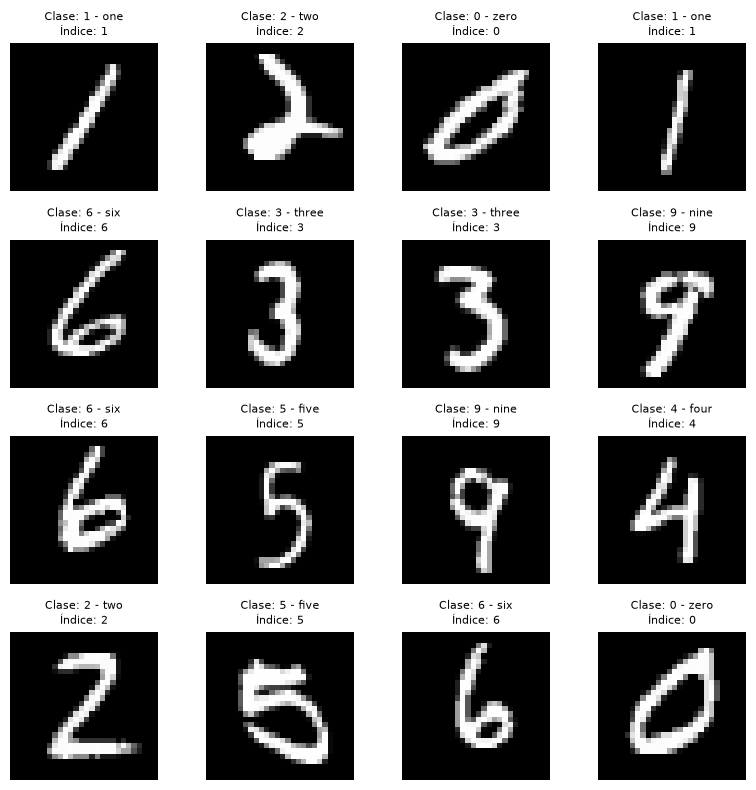

In [8]:
import numpy as np
import matplotlib.pyplot as plt
#!pip install scikit-learn

file_path = './mnist.npz' 

classes = ['0 - zero', '1 - one', '2 - two', '3 - three', '4 - four', '5 - five',
 '6 - six', '7 - seven', '8 - eight', '9 - nine']

d = np.load(file_path)
X = d["data"]
y = d["targets"]

print("X shape:", X.shape)
print("y shape:", y.shape)

sqrt_num_images = 4

random_indices = np.random.randint(0, len(X), size=sqrt_num_images*sqrt_num_images)

grid_size = int(np.sqrt(sqrt_num_images*sqrt_num_images))

plt.figure(figsize=(8, 8))  
for i, idx in enumerate(random_indices):
    plt.subplot(grid_size, grid_size, i+1)
    plt.imshow(X[idx], cmap='gray')
    plt.title(f"Clase: {classes[y[idx]]}\nÍndice: {y[idx]}", fontsize=8)
    plt.axis('off')

plt.tight_layout()
plt.show()

Vamos a filtrar para distinguir "seises" de "ochos"

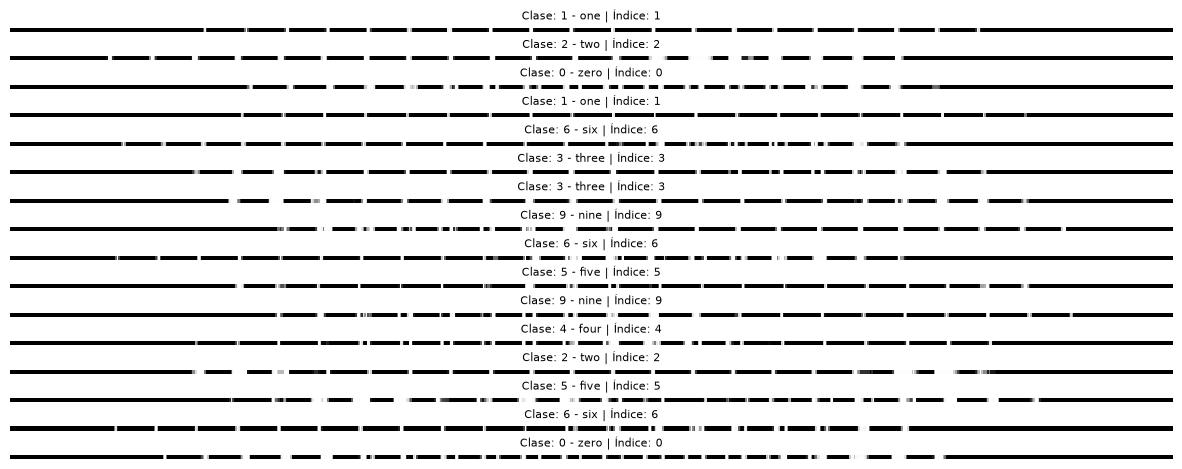

In [9]:
num_images = sqrt_num_images*sqrt_num_images
dataset_size = len(X)

fig_height_per_image = 0.35
plt.figure(figsize=(15, fig_height_per_image*num_images))

for i, idx in enumerate(random_indices):
    plt.subplot(num_images, 1, i+1)
    X_flat = X[idx].reshape(1, 28*28)
    plt.imshow(X_flat, cmap='gray', aspect='auto', interpolation='nearest')
    plt.title(f"Clase: {classes[y[idx]]} | Índice: {y[idx]}", fontsize=8)
    plt.axis('off')

plt.subplots_adjust(hspace=6)
plt.show()

In [10]:
CLASS_1_INDEX = 8 # Clase "positiva"
CLASS_2_INDEX = 6 # Clase "negativa"

mask = (y == CLASS_1_INDEX) | (y == CLASS_2_INDEX)

valid_indices = np.where(mask)[0]

X_filtered = X[valid_indices]
y_filtered = y[valid_indices]

Veamos algunas imágenes del conjunto filtrado:

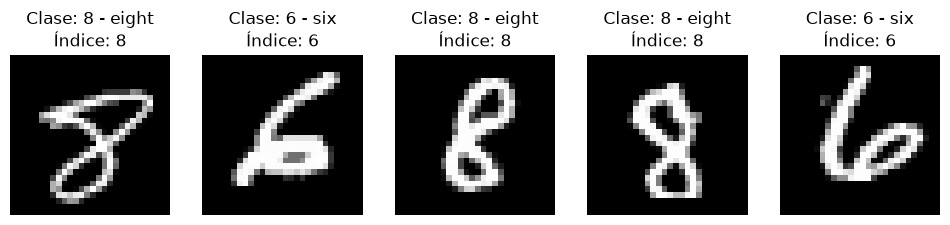

In [11]:
num_images = 5

random_indices = np.random.randint(0, len(X_filtered), size=num_images)

plt.figure(figsize=(12, 3))
for i, idx in enumerate(random_indices):
    plt.subplot(1, num_images, i+1)
    plt.imshow(X_filtered[idx], cmap='gray')
    plt.title(f"Clase: {classes[y_filtered[idx]]}\nÍndice: {y_filtered[idx]}")
    plt.axis('off')
plt.show()

In [13]:
from sklearn.model_selection import train_test_split
# Trabajemos con un 20% de datos de prueba
test_fraction = 0.2

# Dividir los datos en conjuntos de entrenamiento y prueba

X_train = X_filtered[0:int(0.8*len(X_filtered))]
y_train = y_filtered[0:int(0.8*len(y_filtered))]
X_test = X_filtered[int(0.8*len(X_filtered)):]#
y_test = y_filtered[int(0.8*len(y_filtered)):]

print(f"Forma del conjunto de entrenamiento: {X_train.shape}")
print(f"Forma del conjunto de prueba: {X_test.shape}")

Forma del conjunto de entrenamiento: (9415, 28, 28)
Forma del conjunto de prueba: (2354, 28, 28)


In [15]:
# Creación e inicialización del perceptrón
w_inicial = np.zeros(784)#pesos
b_inicial = 0.0

In [24]:
predthres = 0.5 # Umbral de predicción, en principio, 0.5

def sigmoid(z):
  z = np.clip(z, -500, 500) # Para evitar over/underflows
  return 1/(1+np.exp(-z)) 

def predict(w,b,sample_x): 
    x= sample_x.reshape(28*28)
    z = np.dot(w,x) +b
    p = sigmoid(z)
    if p>= 0.5:
        y_pred= 1 #8
    else:
        y_pred= 0 #6
    
    return y_pred 

def hit_rate(w, b, samples_X, samples_y):
    totales = len(samples_y) 
    correcto= 0
    X_flatted= samples_X.reshape(totales,784)

    for i in range(totales):
        y_real= 1 if samples_y[i]==CLASS_1_INDEX else 0
        y_pred= predict(w,b,X_flatted[i,:])
        if y_real == y_pred:
            correcto+=1
    hit= correcto/totales
    return hit 

def train_logres(w_ini, b_ini, samples_X, samples_y, eta=0.1, epochs=10): 
  w = w_ini
  b = b_ini
  for e in range(epochs):
    perm = np.random.permutation(samples_X.shape[0])
    shuffled_X = samples_X[perm]
    shuffled_y = samples_y[perm]
    #print(f"Starting epoch {e+1}");
    for i in range(len(shuffled_X)):
      # actualización parámetros
      x = shuffled_X[i,:].reshape(-1)
      y_real =1 if shuffled_y[i]== CLASS_1_INDEX else 0
      z= np.dot(w,x) +b
      prob = sigmoid(z) 
      w = w - eta*(prob - y_real)*x 
      b = b - eta*(prob - y_real)
    #print(f"Epoch {e+1} hit rate: {hit_rate(w, b, shuffled_X, shuffled_y)}")
  return w, b
CLASS_1_INDEX ==1
CLASS_2_INDEX ==0

False

Entrenamos el perceptrón durante unas pocas épocas, y evaluamos su tasa de acierto con el conjunto de prueba. 

In [25]:
w_inicial = np.zeros(28*28)
b_inicial = 0.0
w,b = train_logres(w_inicial, b_inicial, X_train, y_train, eta=1e-25, epochs=30);

In [26]:
hr = hit_rate(w,b,X_test,y_test)

print(f"Tasa de aciertos: {hr}, ¿conseguido? {'¡Sí, toma ya!' if hr>0.98 else 'Que va...'}")

Tasa de aciertos: 0.9668649107901445, ¿conseguido? Que va...


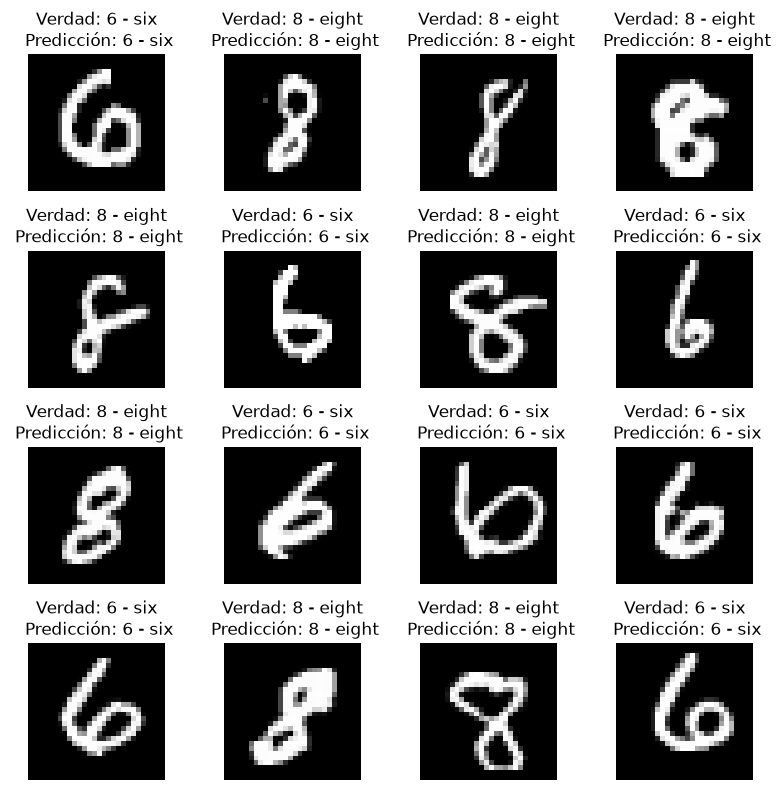

In [27]:
num_images = sqrt_num_images*sqrt_num_images

random_indices = np.random.randint(0, len(X_test), size=num_images)

grid_size = int(np.sqrt(num_images))

plt.figure(figsize=(8, 8))
for i, idx in enumerate(random_indices):
    plt.subplot(grid_size, grid_size, i+1)
    plt.imshow(X_test[idx].reshape(28, 28), cmap='gray')
    p01 = predict(w,b,X_test[idx])
    p = 8 if p01 == 1 else 6
    col = 'black' if classes[y_test[idx]]==classes[p] else 'red'
    plt.title(f"Verdad: {classes[y_test[idx]]}\n Predicción: {classes[p]}", color=col)
    plt.axis('off')

plt.tight_layout()
plt.show()